# RetailRocket Product Analytics - Python Visualization Module


In [4]:
%pip install pyodbc
import pyodbc

print(pyodbc.drivers())

  Using cached pyodbc-5.3.0-cp312-cp312-win_amd64.whl.metadata (2.8 kB)
Note: you may need to restart the kernel to use updated packages.
['SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'ODBC Driver 17 for SQL Server', 'ODBC Driver 18 for SQL Server']



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# %pip install pandas matplotlib sqlalchemy pyodbc

import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from pathlib import Path

OUTPUT_DIR=Path("images")
OUTPUT_DIR.mkdir(exist_ok=True)

SERVER="LAPTOP-NF4758FA\\SQLEXPRESS"
DATABASE="RetailRocket_Product_Analytics"
DRIVER="ODBC Driver 18 for SQL Server"

connection_string = (
    f"mssql+pyodbc://@{SERVER}/{DATABASE}"
    f"?driver={DRIVER.replace(' ','+')}"
    "&trusted_connection=yes"
    "&TrustServerCertificate=yes"
)
engine=create_engine(connection_string)


In [19]:
def run_query(query):
    return pd.read_sql(query, engine)

def display_table_chart(df, title, chart_type="pie", x=None, y=None, filename=None):

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # ---------------- TABLE ----------------
    ax[0].axis("off")

    table = ax[0].table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 2)

    ax[0].set_title(title + " (Table)", fontsize=14, weight="bold")

    # ---------------- CHART ----------------
    if chart_type == "pie":
        plot_df = df.dropna(subset=[x, y])
        
        ax[1].pie(
        plot_df[y],
        labels=plot_df[x],
        autopct="%1.1f%%",
        startangle=90
    )

    elif chart_type == "bar":
        plot_df = df.dropna(subset=[x, y])
        ax[1].bar(plot_df[x].astype(str), plot_df[y])
        ax[1].tick_params(axis='x', rotation=45)

    elif chart_type == "line":
        ax[1].plot(df[x], df[y], marker="o")

    ax[1].set_title(title, fontsize=14, weight="bold")

    plt.tight_layout()
    plt.show()

## 1. Event Distribution

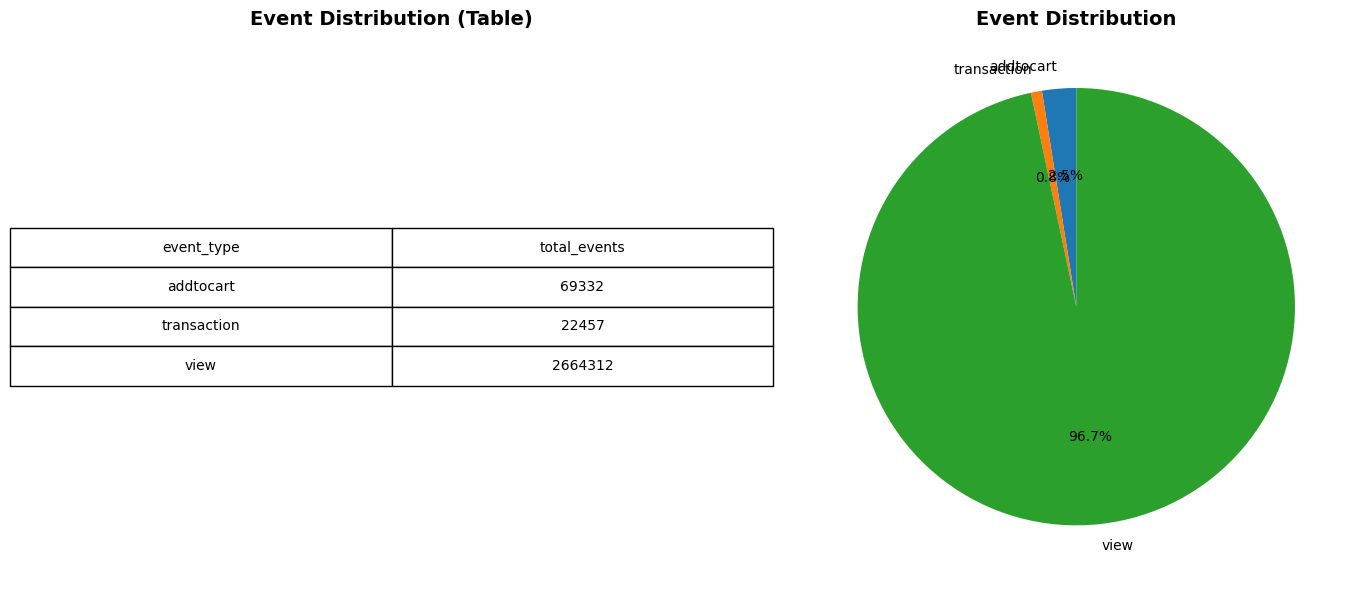

In [7]:
df = run_query("""
SELECT event_type,
       COUNT(*) AS total_events
FROM events
GROUP BY event_type
""")

display_table_chart(
    df,
    title="Event Distribution",
    chart_type="pie",
    x="event_type",
    y="total_events",
    filename="event_distribution.png"
)

## 2. Monthly Activity

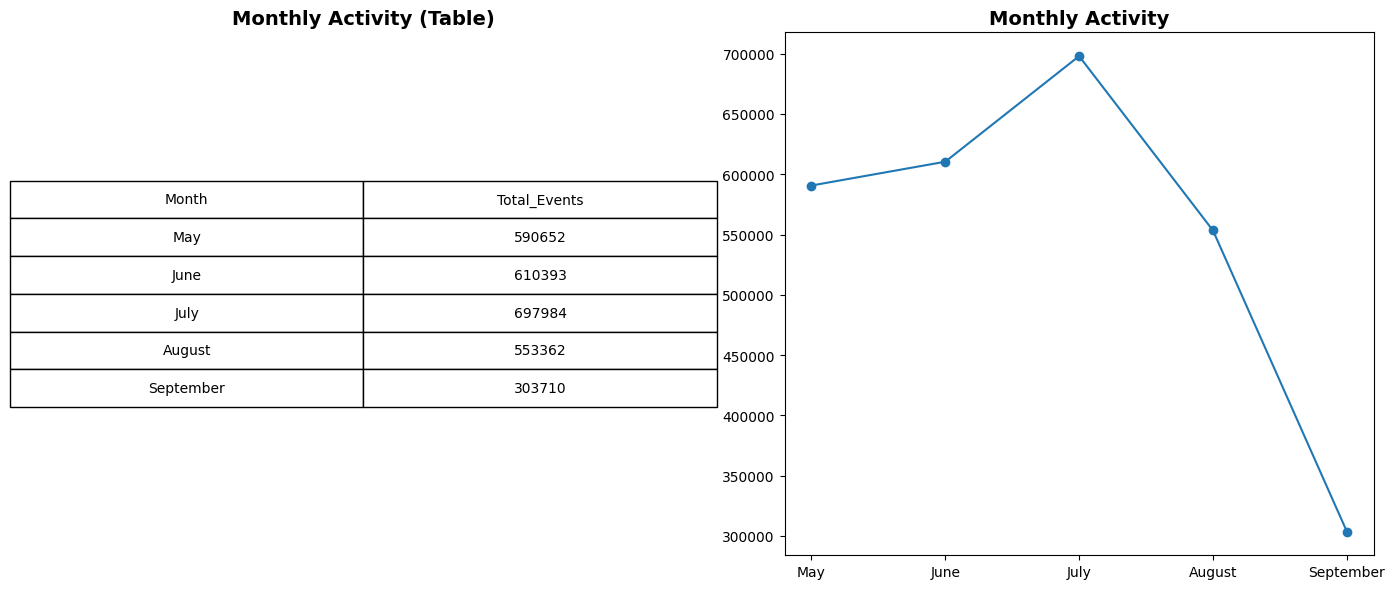

In [9]:
df = run_query("""
SELECT
    DATENAME(MONTH,event_timestamp) AS Month,
    MONTH(event_timestamp) AS Month_No,
    COUNT(*) AS Total_Events
FROM events
GROUP BY
    DATENAME(MONTH,event_timestamp),
    MONTH(event_timestamp)
ORDER BY Month_No
""")

display_table_chart(
    df.drop(columns="Month_No"),
    title="Monthly Activity",
    chart_type="line",
    x="Month",
    y="Total_Events",
    filename="monthly_activity.png"
)

## 3. Hourly Activity

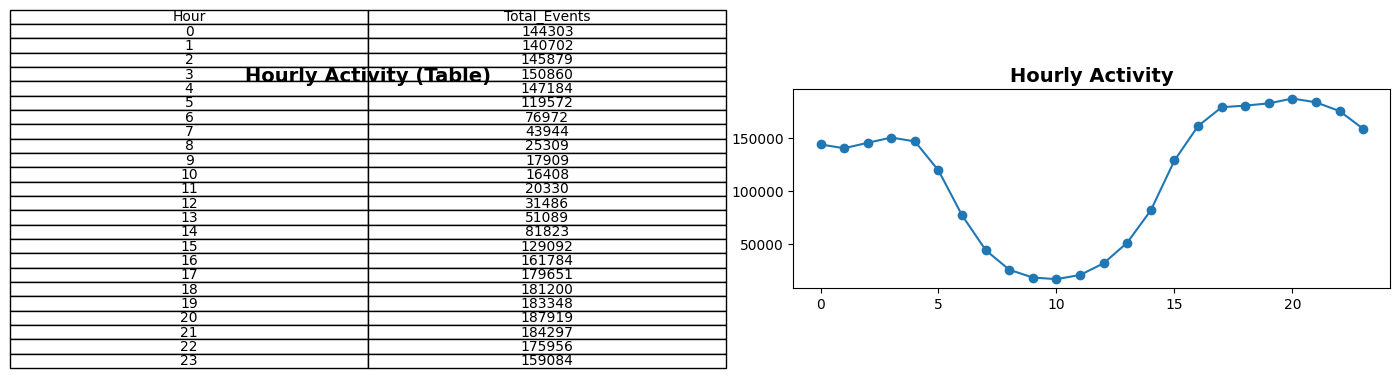

In [10]:
df = run_query("""
SELECT
    DATEPART(HOUR,event_timestamp) AS Hour,
    COUNT(*) AS Total_Events
FROM events
GROUP BY DATEPART(HOUR,event_timestamp)
ORDER BY Hour
""")

display_table_chart(
    df,
    title="Hourly Activity",
    chart_type="line",
    x="Hour",
    y="Total_Events",
    filename="hourly_activity.png"
)

## 4. Funnel Analysis

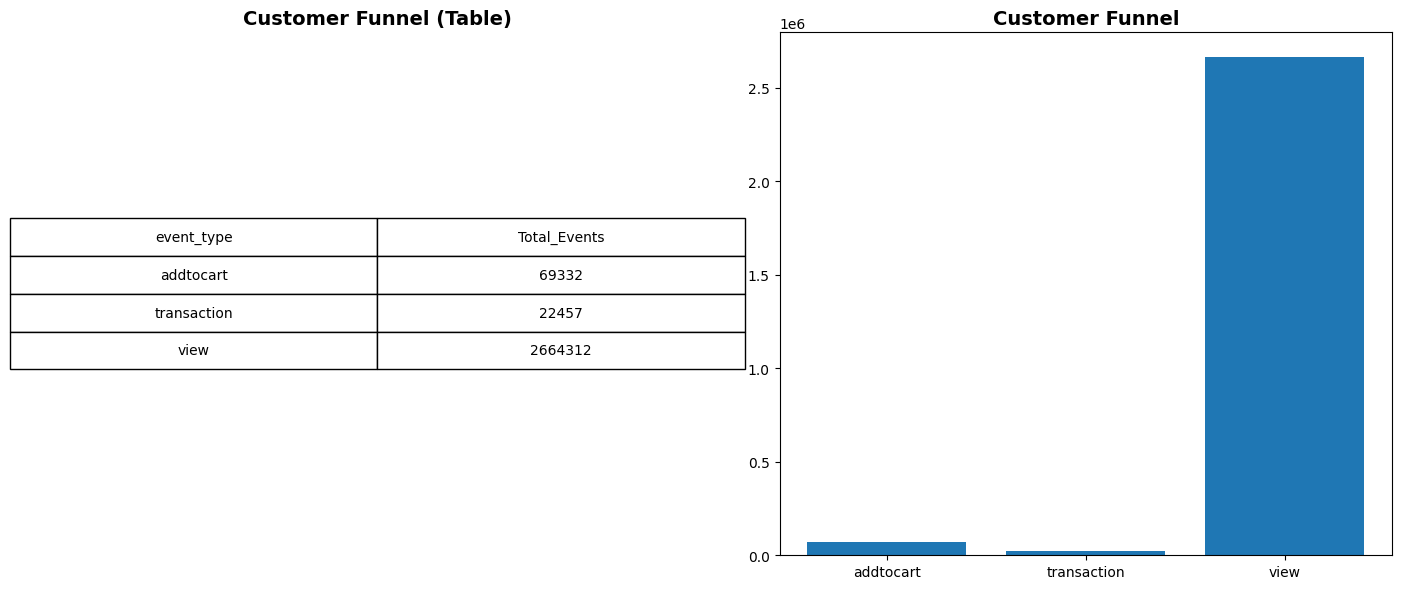

In [11]:
df = run_query("""
SELECT
    event_type,
    COUNT(*) AS Total_Events
FROM events
GROUP BY event_type
""")

display_table_chart(
    df,
    title="Customer Funnel",
    chart_type="bar",
    x="event_type",
    y="Total_Events",
    filename="funnel_analysis.png"
)

## Top Categories

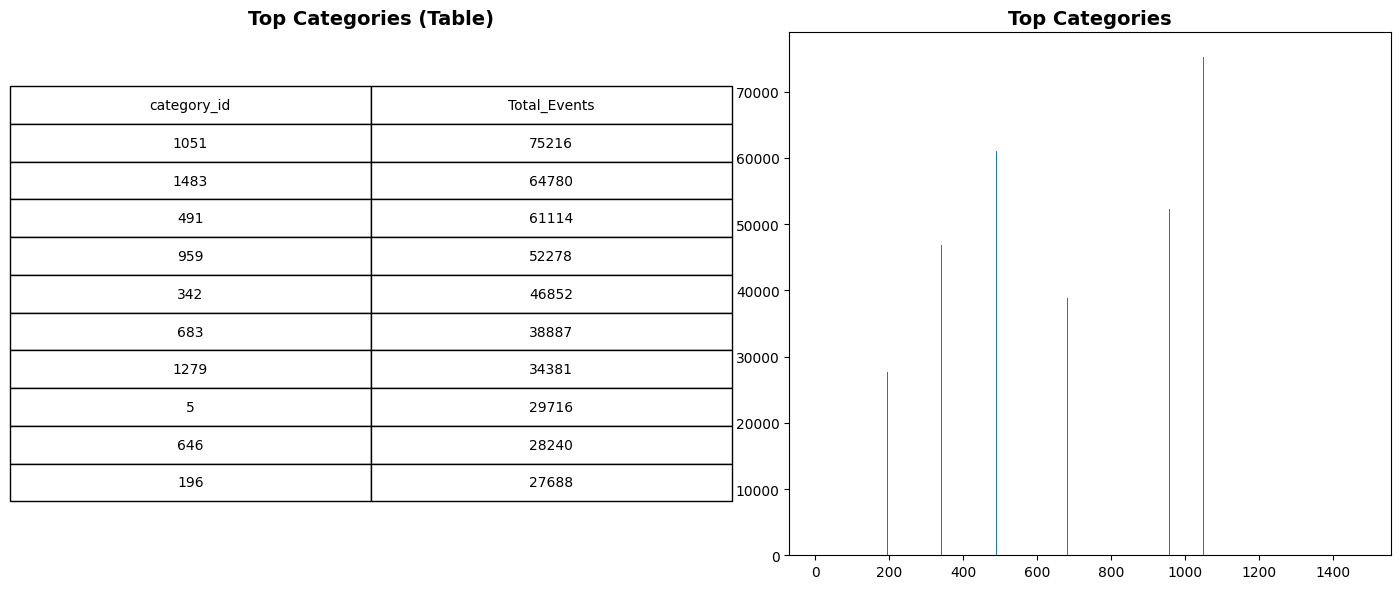

In [12]:
df = run_query("""
SELECT TOP 10
    p.category_id,
    COUNT(*) AS Total_Events
FROM events e
JOIN products p
ON e.item_id = p.item_id
GROUP BY p.category_id
ORDER BY Total_Events DESC
""")

display_table_chart(
    df,
    title="Top Categories",
    chart_type="bar",
    x="category_id",
    y="Total_Events",
    filename="top_categories.png"
)

## Product Availability

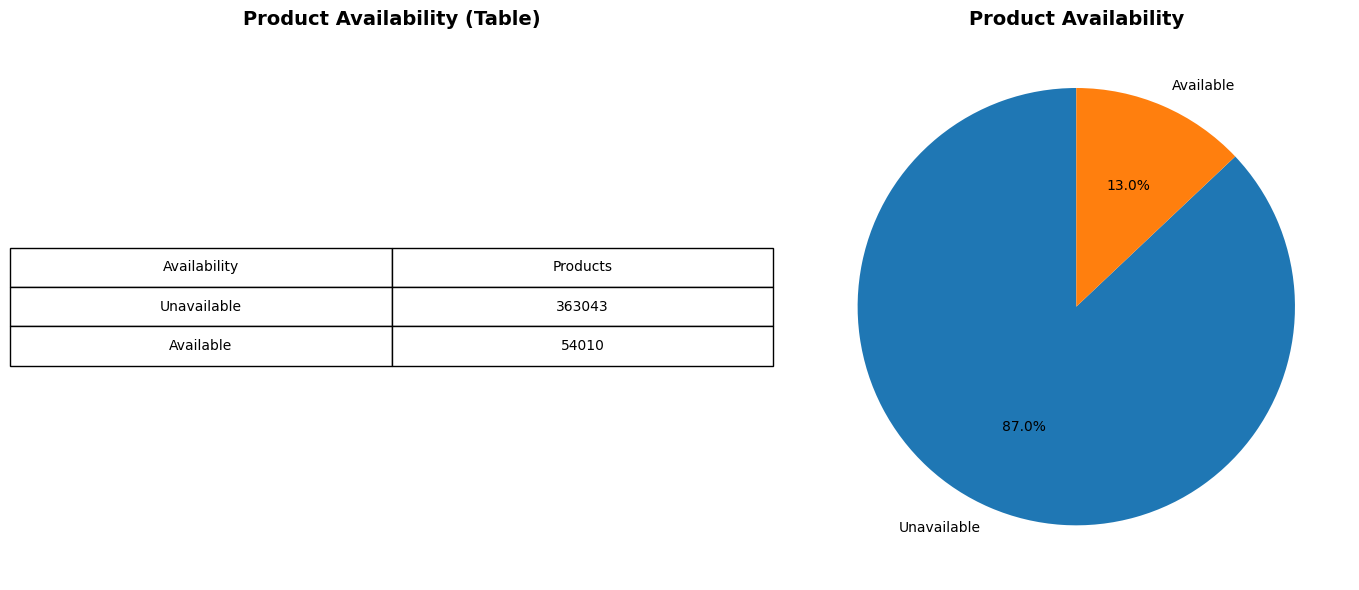

In [13]:
df = run_query("""
SELECT
    CASE
        WHEN available=1 THEN 'Available'
        ELSE 'Unavailable'
    END AS Availability,
    COUNT(*) AS Products
FROM products
GROUP BY available
""")

display_table_chart(
    df,
    title="Product Availability",
    chart_type="pie",
    x="Availability",
    y="Products",
    filename="product_availability.png"
)

## Most Purchased Products

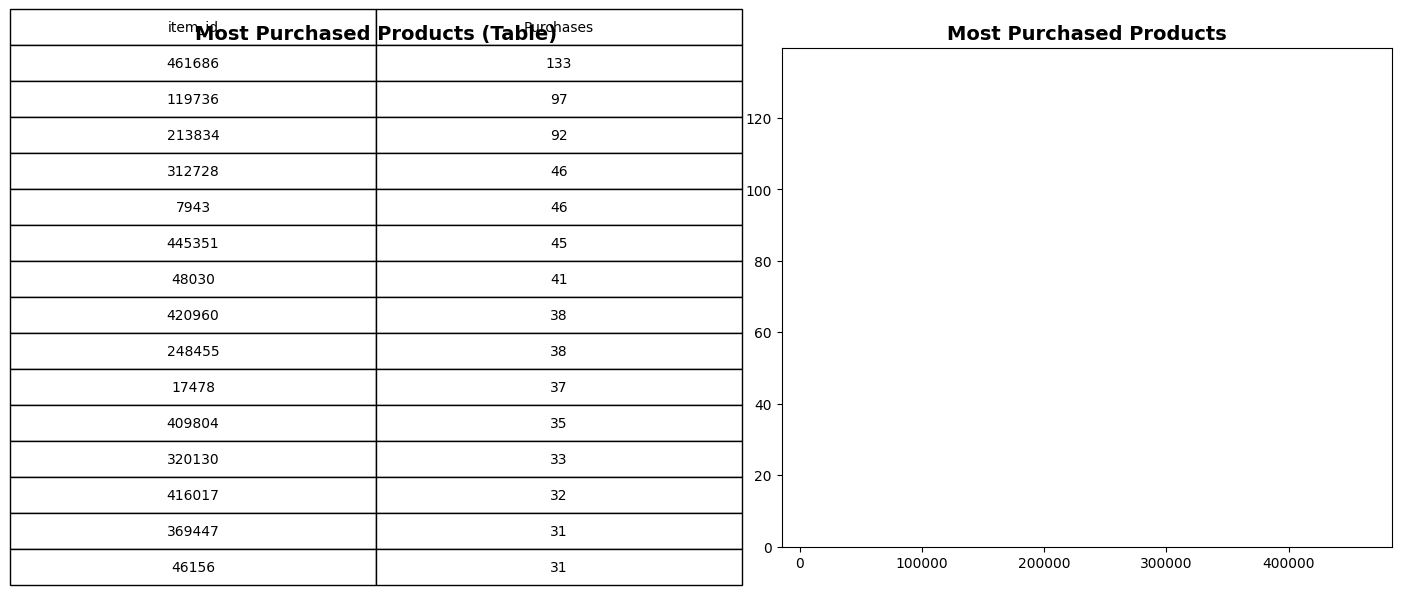

In [14]:
df = run_query("""
SELECT TOP 15
    item_id,
    COUNT(*) AS Purchases
FROM events
WHERE event_type='transaction'
GROUP BY item_id
ORDER BY Purchases DESC
""")

display_table_chart(
    df,
    title="Most Purchased Products",
    chart_type="bar",
    x="item_id",
    y="Purchases",
    filename="purchase_distribution.png"
)

## KPI Dashboard 

In [22]:
df = run_query("""
SELECT

COUNT(*) AS Total_Events,

COUNT(DISTINCT visitor_id) AS Total_Visitors,

COUNT(DISTINCT item_id) AS Total_Products,

SUM(CASE
        WHEN event_type='transaction'
        THEN 1
        ELSE 0
    END) AS Purchases

FROM events
""")

df

,Total_Events,Total_Visitors,Total_Products,Purchases
0,2756101,1407580,235061,22457
